In [1]:
# Imports & Setup 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [2]:
#Data Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # flattening to 28x28 _-> 784
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Input dim     : {train_dataset[0][0].shape[0]}")   # 784

100%|██████████| 9.91M/9.91M [00:00<00:00, 157MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 29.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 41.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


Train samples : 60000
Test  samples : 10000
Input dim     : 784


In [3]:
# Autoencoder Architecture 
class Autoencoder(nn.Module):
    def __init__(self, bottleneck_dim):
        super(Autoencoder, self).__init__()

        #  Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, bottleneck_dim)   # compressed representation
        )

        #Decoder 
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()                     # pixel values in [0, 1]
        )

    def forward(self, x):
        z    = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


# Quick sanity check
_dummy = torch.zeros(4, 784)
for dim in [100, 50, 30, 20]:
    model = Autoencoder(bottleneck_dim=dim)
    out   = model(_dummy)
    print(f"Bottleneck {dim:3d} → output shape: {out.shape}")

Bottleneck 100 → output shape: torch.Size([4, 784])
Bottleneck  50 → output shape: torch.Size([4, 784])
Bottleneck  30 → output shape: torch.Size([4, 784])
Bottleneck  20 → output shape: torch.Size([4, 784])


In [4]:
# AE Training Function 
def train_autoencoder(bottleneck_dim, epochs=20, lr=1e-3):
    """
    Trains an Autoencoder with the given bottleneck dimension.
    Returns the trained model and per-epoch train loss list.
    """
    model     = Autoencoder(bottleneck_dim=bottleneck_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    #criterion = nn.BCELoss()
    train_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)

            #Forward pass 
            x_hat = model(x_batch)

            #Loss
            loss = criterion(x_hat, x_batch)

            #Backward pass 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x_batch.size(0)

        avg_loss = epoch_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [Bottleneck={bottleneck_dim}] Epoch {epoch:02d}/{epochs} "
                  f"| Train MSE Loss: {avg_loss:.6f}")

    return model, train_losses


#  Compute reconstruction error on test set 
def compute_reconstruction_error(model):
    """Returns average MSE reconstruction error on the test set."""
    model.eval()
    criterion = nn.MSELoss()
    total_loss = 0.0

    with torch.no_grad():
        for x_batch, _ in test_loader:
            x_batch = x_batch.to(device)
            x_hat   = model(x_batch)
            loss    = criterion(x_hat, x_batch)
            total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(test_loader.dataset)

In [5]:
# # Train AE for all bottleneck dimensions
bottleneck_dims = [100, 50, 30, 20]
ae_models = {}
ae_losses = {}
ae_recon_errors = {}

for dim in bottleneck_dims:
    print(f"\nTraining Autoencoder with bottleneck dim = {dim}")
    model, losses = train_autoencoder(bottleneck_dim=dim, epochs=20)
    recon_error   = compute_reconstruction_error(model)

    ae_models[dim]       = model
    ae_losses[dim]       = losses
    ae_recon_errors[dim] = recon_error

    print(f"  Test Reconstruction Error (MSE): {recon_error:.6f}")

# Summary table
print("\n--- Reconstruction Error Summary ---")
print(f"{'Bottleneck Dim':<20} {'Test MSE':<15}")
print("-" * 35)
for dim in bottleneck_dims:
    print(f"{dim:<20} {ae_recon_errors[dim]:<15.6f}")


Training Autoencoder with bottleneck dim = 100
  [Bottleneck=100] Epoch 01/20 | Train MSE Loss: 0.043438
  [Bottleneck=100] Epoch 05/20 | Train MSE Loss: 0.008839
  [Bottleneck=100] Epoch 10/20 | Train MSE Loss: 0.005791
  [Bottleneck=100] Epoch 15/20 | Train MSE Loss: 0.004649
  [Bottleneck=100] Epoch 20/20 | Train MSE Loss: 0.004005
  Test Reconstruction Error (MSE): 0.004221

Training Autoencoder with bottleneck dim = 50
  [Bottleneck=50] Epoch 01/20 | Train MSE Loss: 0.042445
  [Bottleneck=50] Epoch 05/20 | Train MSE Loss: 0.009177
  [Bottleneck=50] Epoch 10/20 | Train MSE Loss: 0.006211
  [Bottleneck=50] Epoch 15/20 | Train MSE Loss: 0.005003
  [Bottleneck=50] Epoch 20/20 | Train MSE Loss: 0.004310
  Test Reconstruction Error (MSE): 0.004611

Training Autoencoder with bottleneck dim = 30
  [Bottleneck=30] Epoch 01/20 | Train MSE Loss: 0.042821
  [Bottleneck=30] Epoch 05/20 | Train MSE Loss: 0.009458
  [Bottleneck=30] Epoch 10/20 | Train MSE Loss: 0.006468
  [Bottleneck=30] Epoch 

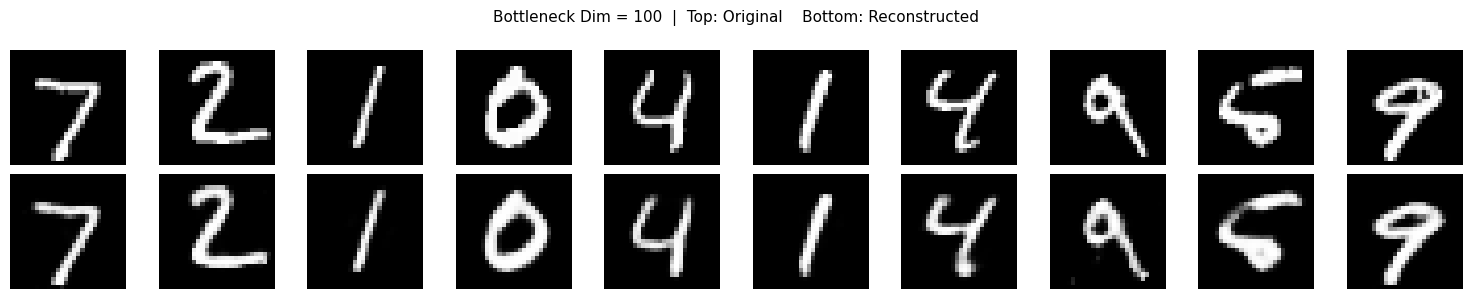

Saved reconstruction plot for bottleneck dim = 100


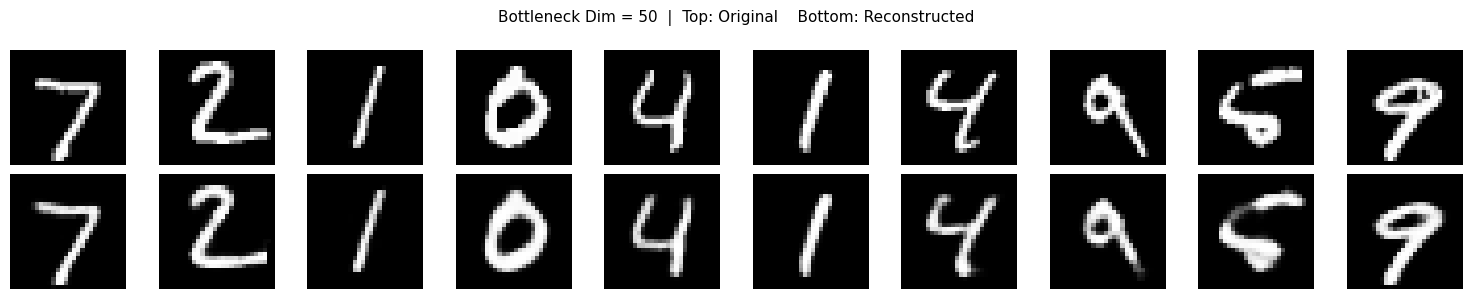

Saved reconstruction plot for bottleneck dim = 50


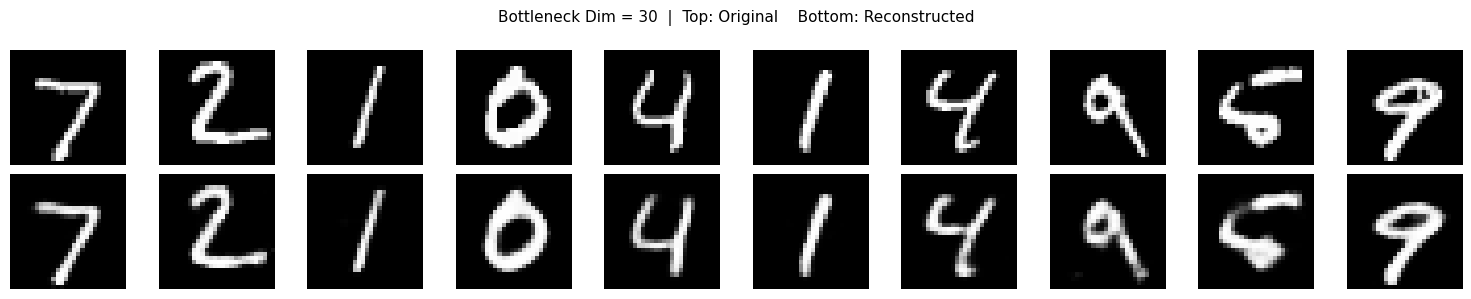

Saved reconstruction plot for bottleneck dim = 30


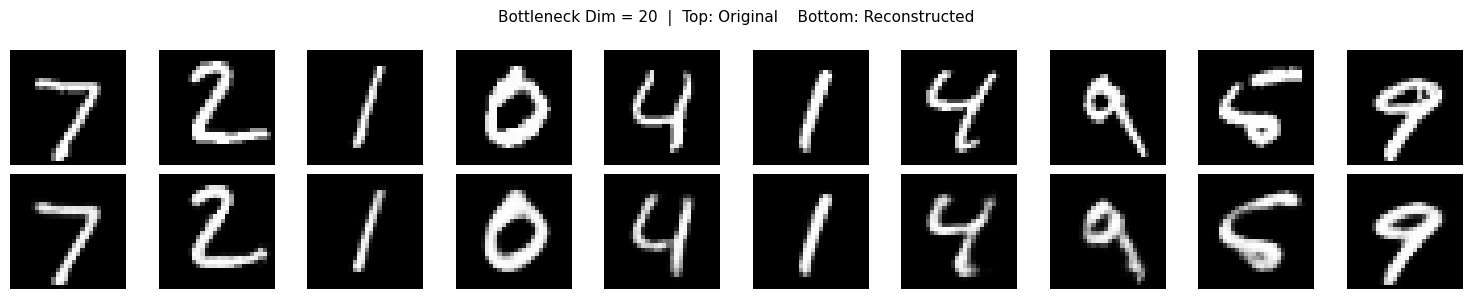

Saved reconstruction plot for bottleneck dim = 20


In [6]:
# Visualize reconstructed digits for each bottleneck dimension

def show_reconstructions(model, bottleneck_dim, n=10):
    model.eval()
    
    # grab one batch from test set
    x_batch, labels = next(iter(test_loader))
    x_batch = x_batch.to(device)
    
    with torch.no_grad():
        x_hat = model(x_batch)
    
    # move to cpu for plotting
    x_orig = x_batch.cpu().numpy()
    x_recon = x_hat.cpu().numpy()
    
    fig, axes = plt.subplots(2, n, figsize=(15, 3))
    fig.suptitle(f"Bottleneck Dim = {bottleneck_dim}  |  Top: Original    Bottom: Reconstructed", 
                 fontsize=11)
    
    for i in range(n):
        # original
        axes[0, i].imshow(x_orig[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        
        # reconstructed
        axes[1, i].imshow(x_recon[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'ae_reconstruction_dim_{bottleneck_dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved reconstruction plot for bottleneck dim = {bottleneck_dim}")


# plot reconstructions for all trained models
for dim in bottleneck_dims:
    show_reconstructions(ae_models[dim], bottleneck_dim=dim)

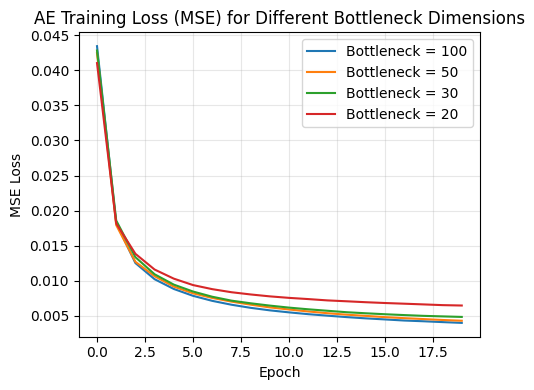

Saved AE loss curves plot


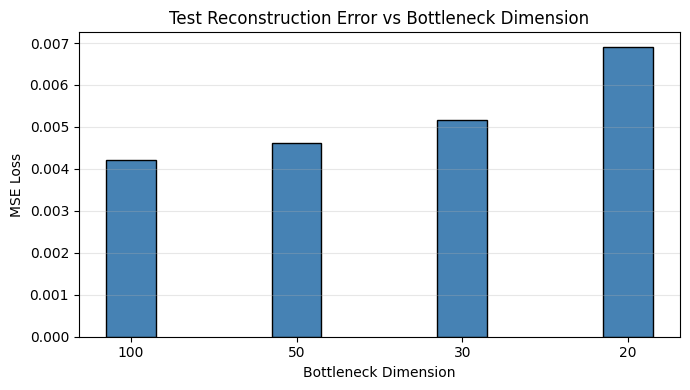

Saved reconstruction error bar chart


In [7]:
# Plottig training loss curves for all bottleneck dimensions

plt.figure(figsize=(5, 4))

for dim in bottleneck_dims:
    plt.plot(ae_losses[dim], label=f'Bottleneck = {dim}')

plt.title('AE Training Loss (MSE) for Different Bottleneck Dimensions')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ae_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved AE loss curves plot")


# also plot a simple bar chart of final test reconstruction errors
plt.figure(figsize=(7, 4))
dims   = list(ae_recon_errors.keys())
errors = list(ae_recon_errors.values())

plt.bar([str(d) for d in dims], errors, color='steelblue', edgecolor='black', width=0.3)
plt.title('Test Reconstruction Error vs Bottleneck Dimension')
plt.xlabel('Bottleneck Dimension')
plt.ylabel('MSE Loss')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ae_recon_error_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved reconstruction error bar chart")

# **VAE Architecture (2D Latent Space)**

In [8]:
# VAE Architecture with 2D latent space
# Encoder outputs two means and two standard deviations
# Reparameterization trick is used to sample the latent variable

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # encoder network - compresses input to hidden representation
        self.encoder_net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        # two separate heads for mean and log variance
        self.fc_mu      = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

        # decoder network - reconstructs image from latent variable
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        # pass through shared encoder layers
        h = self.encoder_net(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
    # reparameterization trick: allows gradients to flow through
    # sampling by expressing z = mu + eps*std where eps ~ N(0,I)
    # this keeps the stochastic node outside the computational graph
        if self.training:
        std = torch.exp(0.5 * log_var)  # convert log_var to std
        eps = torch.randn_like(std)      # sample noise
            return mu + eps * std            # differentiable sample
        else:
        # during eval/visualization return mu directly
        # generation uses decode(z) directly so this only
        # affects latent space visualization — means only, as required
            return mu

    def decode(self, z):
        return self.decoder_net(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        x_hat       = self.decode(z)
        return x_hat, mu, log_var


# sanity check
vae_test = VAE(latent_dim=2).to(device)
dummy    = torch.zeros(4, 784).to(device)
out, mu, lv = vae_test(dummy)
print(f"Input shape     : {dummy.shape}")
print(f"Output shape    : {out.shape}")
print(f"Mu shape        : {mu.shape}")
print(f"Log Var shape   : {lv.shape}")

Input shape     : torch.Size([4, 784])
Output shape    : torch.Size([4, 784])
Mu shape        : torch.Size([4, 2])
Log Var shape   : torch.Size([4, 2])


In [9]:
# VAE Loss Function
# Total VAE loss = Reconstruction loss (BCE) + KL Divergence
# BCE is used here because VAE has a proper probabilistic interpretation
# KL divergence regularizes the latent space to be close to standard normal N(0,1)

def vae_loss(x, x_hat, mu, log_var):
    # reconstruction loss - how well did the decoder reconstruct the input
    # sum over pixels then average over batch (standard practice for VAE)
    recon_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')

    # KL divergence loss - pushes latent distribution toward N(0,1)
    # closed form KL between N(mu, sigma^2) and N(0,1):
    # KL = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # total loss averaged over batch size
    batch_size = x.size(0)
    total_loss = (recon_loss + kl_loss) / batch_size

    return total_loss, recon_loss / batch_size, kl_loss / batch_size


# quick sanity check to make sure loss runs without errors
vae_test.train()
dummy_x    = torch.zeros(4, 784).to(device)
out, mu, lv = vae_test(dummy_x)
loss, rl, kl = vae_loss(dummy_x, out, mu, lv)
print(f"Total Loss : {loss.item():.4f}")
print(f"Recon Loss : {rl.item():.4f}")
print(f"KL Loss    : {kl.item():.4f}")

Total Loss : 545.0132
Recon Loss : 545.0106
KL Loss    : 0.0026


In [10]:
# VAE Training Loop

def train_vae(latent_dim=2, epochs=20, lr=1e-3):
    torch.manual_seed(42)  # ensure reproducibility
    """
    Trains a VAE with the given latent dimension.
    Returns the trained model and per-epoch loss history.
    """
    model     = VAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'total' : [],
        'recon' : [],
        'kl'    : []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss_sum = 0.0
        recon_loss_sum = 0.0
        kl_loss_sum    = 0.0

        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)

            # forward pass
            x_hat, mu, log_var = model(x_batch)

            # compute loss
            loss, recon_loss, kl_loss = vae_loss(x_batch, x_hat, mu, log_var)

            # backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss_sum += loss.item()
            recon_loss_sum += recon_loss.item()
            kl_loss_sum    += kl_loss.item()

        # average over number of batches
        num_batches = len(train_loader)
        history['total'].append(total_loss_sum / num_batches)
        history['recon'].append(recon_loss_sum / num_batches)
        history['kl'].append(kl_loss_sum    / num_batches)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [Latent Dim={latent_dim}] Epoch {epoch:02d}/{epochs}"
                  f"  |  Total: {history['total'][-1]:.2f}"
                  f"  |  Recon: {history['recon'][-1]:.2f}"
                  f"  |  KL: {history['kl'][-1]:.2f}")

    return model, history


# train the 2D VAE
print("Training VAE with 2D latent space...")
vae_2d, history_2d = train_vae(latent_dim=2, epochs=20)

# save the trained model
torch.save(vae_2d.state_dict(), 'vae_2d.pth')
print("Model saved as vae_2d.pth")

Training VAE with 2D latent space...
  [Latent Dim=2] Epoch 01/20  |  Total: 184.89  |  Recon: 181.31  |  KL: 3.58
  [Latent Dim=2] Epoch 05/20  |  Total: 149.13  |  Recon: 143.12  |  KL: 6.01
  [Latent Dim=2] Epoch 10/20  |  Total: 143.57  |  Recon: 137.15  |  KL: 6.42
  [Latent Dim=2] Epoch 15/20  |  Total: 140.94  |  Recon: 134.33  |  KL: 6.61
  [Latent Dim=2] Epoch 20/20  |  Total: 139.59  |  Recon: 132.86  |  KL: 6.73
Model saved as vae_2d.pth


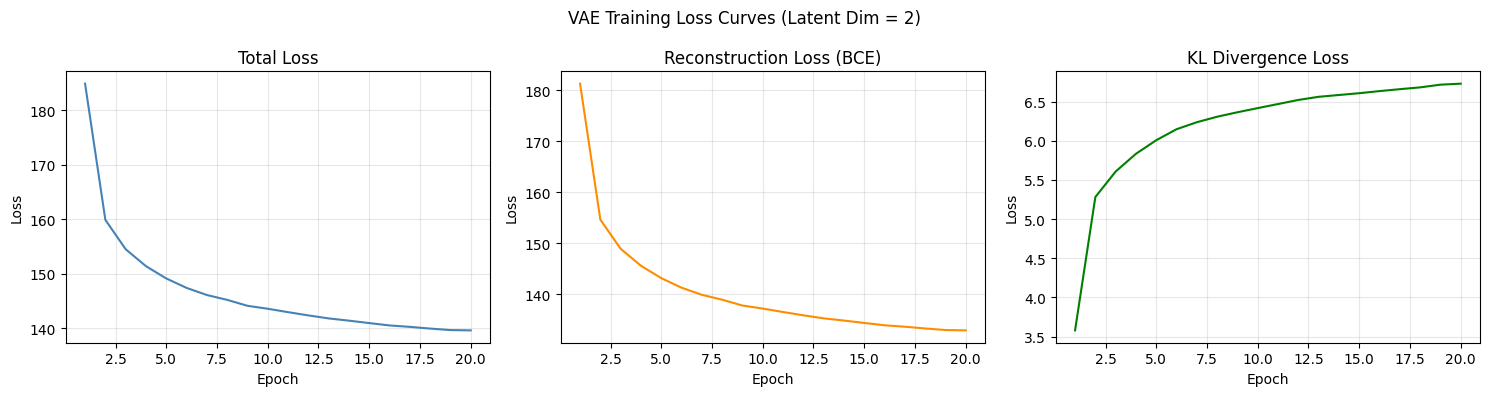

Saved VAE loss curves for latent dim = 2


In [11]:
# Plot VAE training loss curves
# we plot total, reconstruction and KL loss separately
# this helps understand how each component contributes during training

def plot_vae_loss(history, latent_dim):
    epochs = range(1, len(history['total']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'VAE Training Loss Curves (Latent Dim = {latent_dim})', fontsize=12)

    # total loss
    axes[0].plot(epochs, history['total'], color='steelblue')
    axes[0].set_title('Total Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    # reconstruction loss
    axes[1].plot(epochs, history['recon'], color='darkorange')
    axes[1].set_title('Reconstruction Loss (BCE)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)

    # KL divergence loss
    axes[2].plot(epochs, history['kl'], color='green')
    axes[2].set_title('KL Divergence Loss')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'vae_loss_curves_dim_{latent_dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved VAE loss curves for latent dim = {latent_dim}")


plot_vae_loss(history_2d, latent_dim=2)

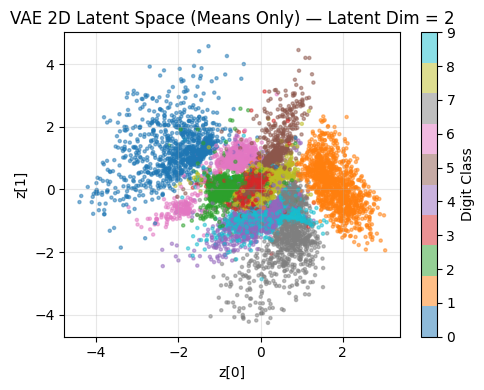

Saved latent space plot for latent dim = 2


In [12]:
# Visualize the 2D latent space color coded by digit class
# we pass the entire test set through the encoder and collect the means
# means are used (not sampled z) because they give a stable representation

def plot_latent_space(model, latent_dim=2):
    model.eval()

    all_mu     = []
    all_labels = []

    with torch.no_grad():
        for x_batch, labels in test_loader:
            x_batch = x_batch.to(device)
            mu, _   = model.encode(x_batch)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())

    all_mu     = np.concatenate(all_mu,     axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    plt.figure(figsize=(5, 4))
    scatter = plt.scatter(
        all_mu[:, 0],
        all_mu[:, 1],
        c=all_labels,
        cmap='tab10',
        alpha=0.5,
        s=5
    )
    plt.colorbar(scatter, label='Digit Class')
    plt.title(f'VAE 2D Latent Space (Means Only) — Latent Dim = {latent_dim}')
    plt.xlabel('z[0]')
    plt.ylabel('z[1]')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'vae_latent_space_dim_{latent_dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved latent space plot for latent dim = {latent_dim}")


plot_latent_space(vae_2d, latent_dim=2)

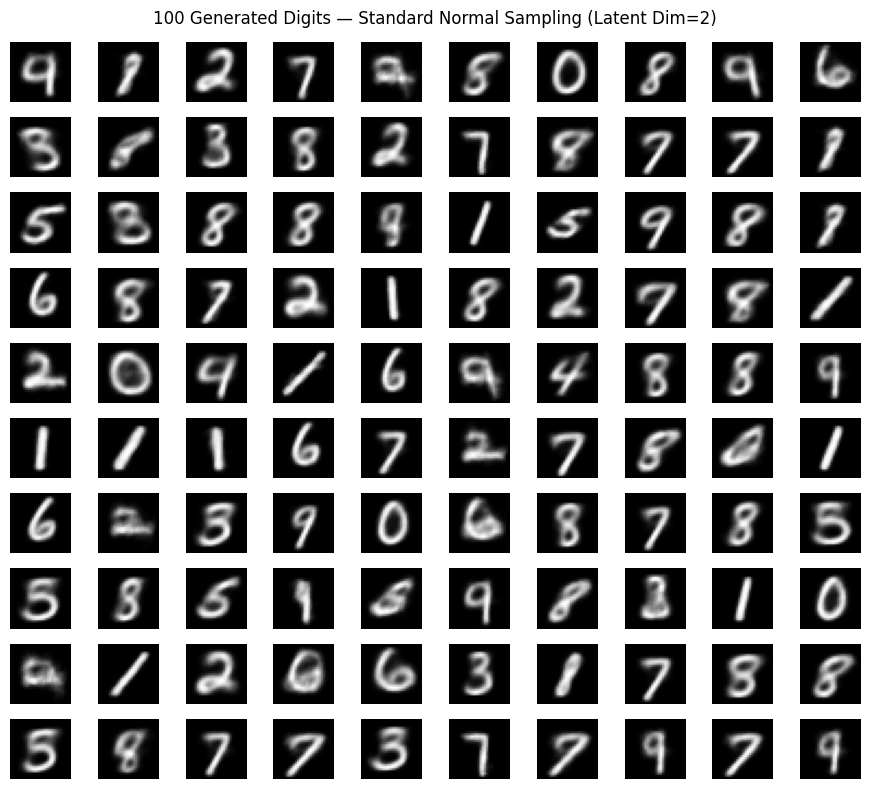

Saved standard normal generated digits for latent dim = 2


In [13]:
# Block 13: Generate 100 digits using randomly sampled latent vectors
# we sample z from standard normal N(0,1) and pass through the decoder
# results are shown as a 10x10 grid

def generate_digits_standard_normal(model, latent_dim=2, n=100):
    model.eval()

    with torch.no_grad():
        # sample 100 latent vectors from standard normal
        z = torch.randn(n, latent_dim).to(device)

        # pass through decoder
        generated = model.decode(z)

    generated = generated.cpu().numpy()

    # plot as 10x10 grid
    fig, axes = plt.subplots(10, 10, figsize=(9, 8))
    fig.suptitle(f'100 Generated Digits — Standard Normal Sampling (Latent Dim={latent_dim})',
                 fontsize=12)

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated[i].reshape(28, 28), cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'vae_generated_standard_normal_dim_{latent_dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved standard normal generated digits for latent dim = {latent_dim}")


generate_digits_standard_normal(vae_2d, latent_dim=2)

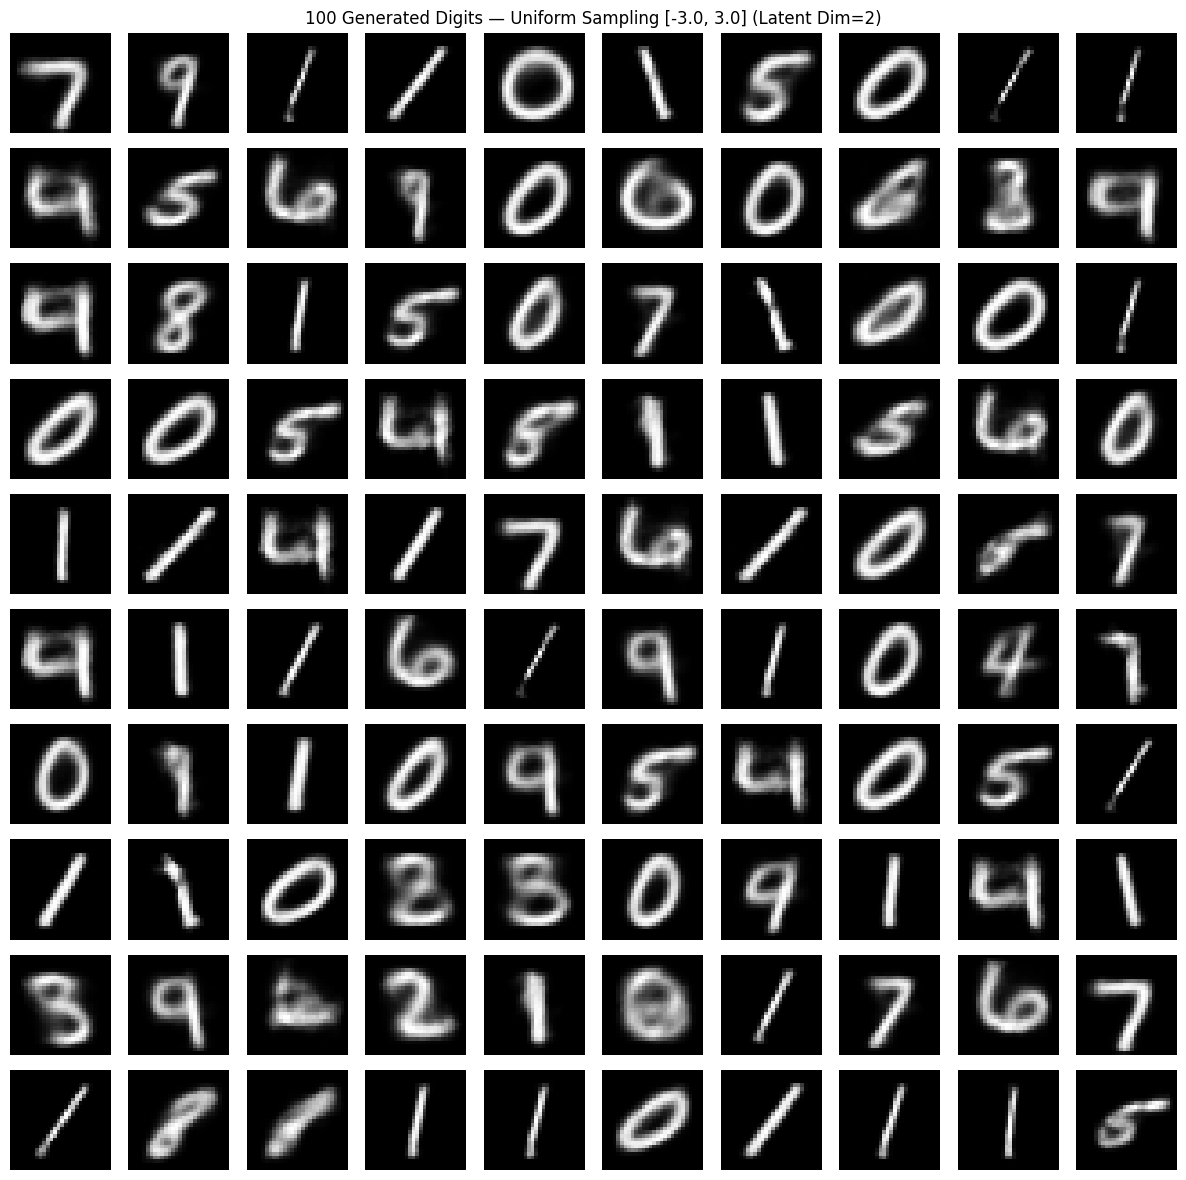

Saved uniform sampled generated digits for latent dim = 2


In [14]:
# Block 14: Generate 100 digits using uniform random sampling of the latent space
# uniform sampling covers the entire latent space evenly including empty regions
# this helps us identify holes - regions where the decoder produces garbage output

def generate_digits_uniform(model, latent_dim=2, n=100, low=-3.0, high=3.0):
    model.eval()

    with torch.no_grad():
        # sample 100 latent vectors uniformly between low and high
        z = torch.FloatTensor(n, latent_dim).uniform_(low, high).to(device)

        # pass through decoder
        generated = model.decode(z)

    generated = generated.cpu().numpy()

    # plot as 10x10 grid
    fig, axes = plt.subplots(10, 10, figsize=(12, 12))
    fig.suptitle(f'100 Generated Digits — Uniform Sampling [{low}, {high}] (Latent Dim={latent_dim})',
                 fontsize=12)

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated[i].reshape(28, 28), cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'vae_generated_uniform_dim_{latent_dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved uniform sampled generated digits for latent dim = {latent_dim}")


generate_digits_uniform(vae_2d, latent_dim=2)

Training VAE with 10D latent space...
  [Latent Dim=10] Epoch 01/20  |  Total: 172.75  |  Recon: 164.85  |  KL: 7.90
  [Latent Dim=10] Epoch 05/20  |  Total: 110.76  |  Recon: 93.81  |  KL: 16.95
  [Latent Dim=10] Epoch 10/20  |  Total: 104.45  |  Recon: 86.12  |  KL: 18.33
  [Latent Dim=10] Epoch 15/20  |  Total: 102.05  |  Recon: 83.35  |  KL: 18.70
  [Latent Dim=10] Epoch 20/20  |  Total: 100.66  |  Recon: 81.78  |  KL: 18.88
Model saved as vae_10d.pth


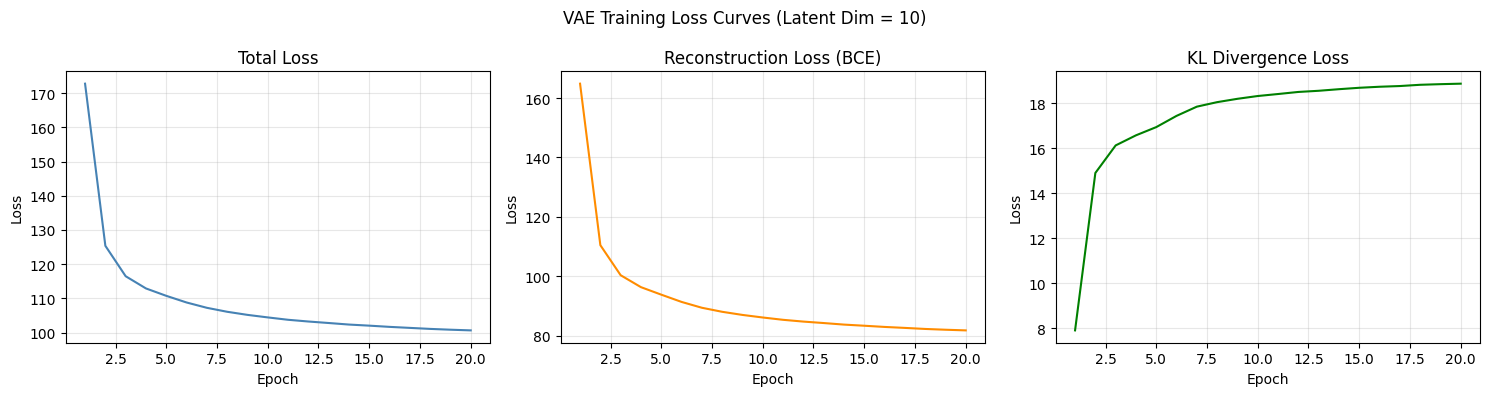

Saved VAE loss curves for latent dim = 10


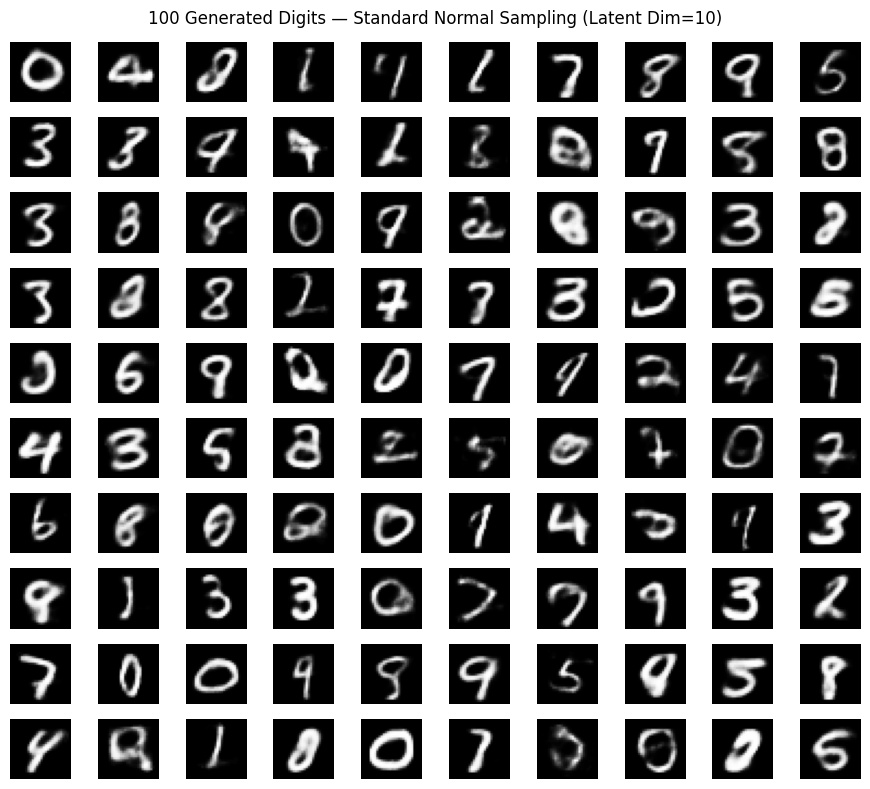

Saved standard normal generated digits for latent dim = 10


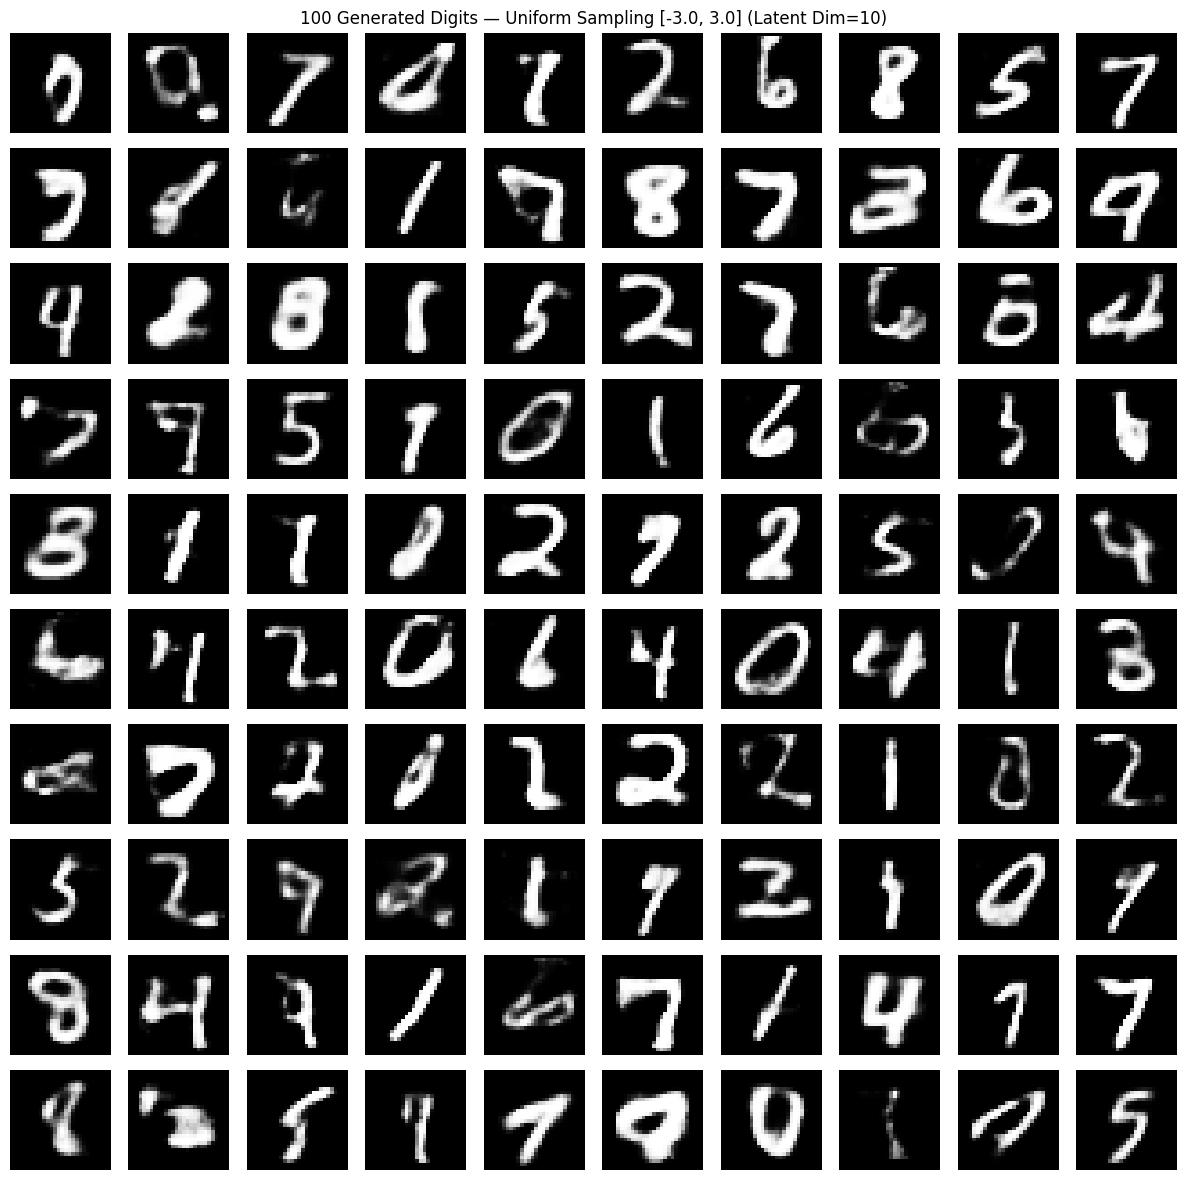

Saved uniform sampled generated digits for latent dim = 10


In [15]:
# Block 15: Train VAE with 10D latent space and compare with 2D
# higher dimensional latent space gives the model more capacity
# but makes visualization harder and introduces more holes in uniform sampling

print("Training VAE with 10D latent space...")
vae_10d, history_10d = train_vae(latent_dim=10, epochs=20)

# save the 10D model
torch.save(vae_10d.state_dict(), 'vae_10d.pth')
print("Model saved as vae_10d.pth")

# plot loss curves for 10D
plot_vae_loss(history_10d, latent_dim=10)

# generate digits using standard normal sampling for 10D
generate_digits_standard_normal(vae_10d, latent_dim=10, n=100)

# generate digits using uniform sampling for 10D
generate_digits_uniform(vae_10d, latent_dim=10, n=100, low=-3.0, high=3.0)

In [16]:
# compare final loss values between 2D and 10D side by side
print("\n--- VAE Loss Comparison: 2D vs 10D ---")
print(f"{'Metric':<25} {'2D VAE':<15} {'10D VAE':<15}")
print("-" * 55)

metrics = ['total', 'recon', 'kl']
for m in metrics:
    val_2d  = history_2d[m][-1]
    val_10d = history_10d[m][-1]
    print(f"{m.capitalize() + ' Loss':<25} {val_2d:<15.2f} {val_10d:<15.2f}")


--- VAE Loss Comparison: 2D vs 10D ---
Metric                    2D VAE          10D VAE        
-------------------------------------------------------
Total Loss                139.59          100.66         
Recon Loss                132.86          81.78          
Kl Loss                   6.73            18.88          


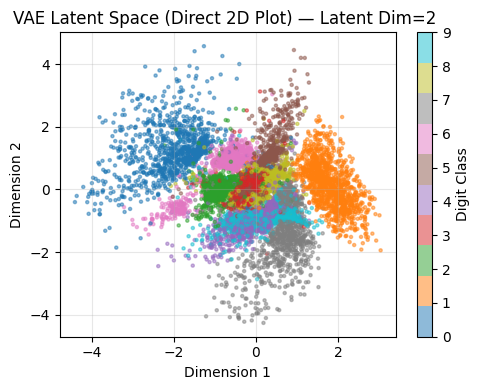

Saved latent space plot for latent dim = 2
Running t-SNE on 10000 points in 10D...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


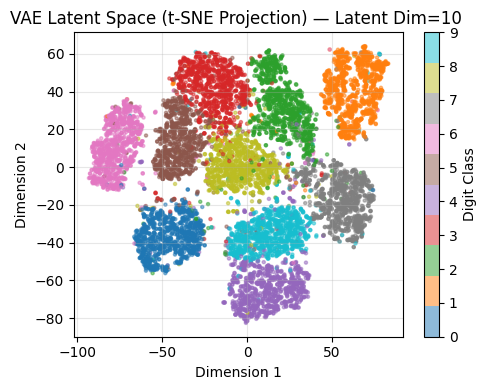

Saved latent space plot for latent dim = 10


In [20]:
# Visualizing 10D latent space using t-SNE
# since 10D cannot be plotted directly we reduce to 2D using t-SNE
# t-SNE preserves local structure so clusters should still be visible
# we also plot 2D VAE latent space side by side for comparison

from sklearn.manifold import TSNE

def plot_latent_space_tsne(model, latent_dim, title_suffix=''):
    model.eval()

    all_mu     = []
    all_labels = []

    with torch.no_grad():
        for x_batch, labels in test_loader:
            x_batch = x_batch.to(device)
            mu, _   = model.encode(x_batch)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())

    all_mu     = np.concatenate(all_mu,     axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # if latent dim is 2 plot directly, otherwise use t-SNE
    if latent_dim == 2:
        reduced = all_mu
        method  = 'Direct 2D Plot'
    else:
        print(f"Running t-SNE on {all_mu.shape[0]} points in {latent_dim}D...")
        tsne    = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
        reduced = tsne.fit_transform(all_mu)
        method  = 't-SNE Projection'

    plt.figure(figsize=(5, 4))
    scatter = plt.scatter(
        reduced[:, 0],
        reduced[:, 1],
        c=all_labels,
        cmap='tab10',
        alpha=0.5,
        s=5
    )
    plt.colorbar(scatter, label='Digit Class')
    plt.title(f'VAE Latent Space ({method}) — Latent Dim={latent_dim} {title_suffix}')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'vae_latent_space_tsne_dim_{latent_dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved latent space plot for latent dim = {latent_dim}")


# plot latent space for both models
plot_latent_space_tsne(vae_2d,  latent_dim=2)
plot_latent_space_tsne(vae_10d, latent_dim=10)

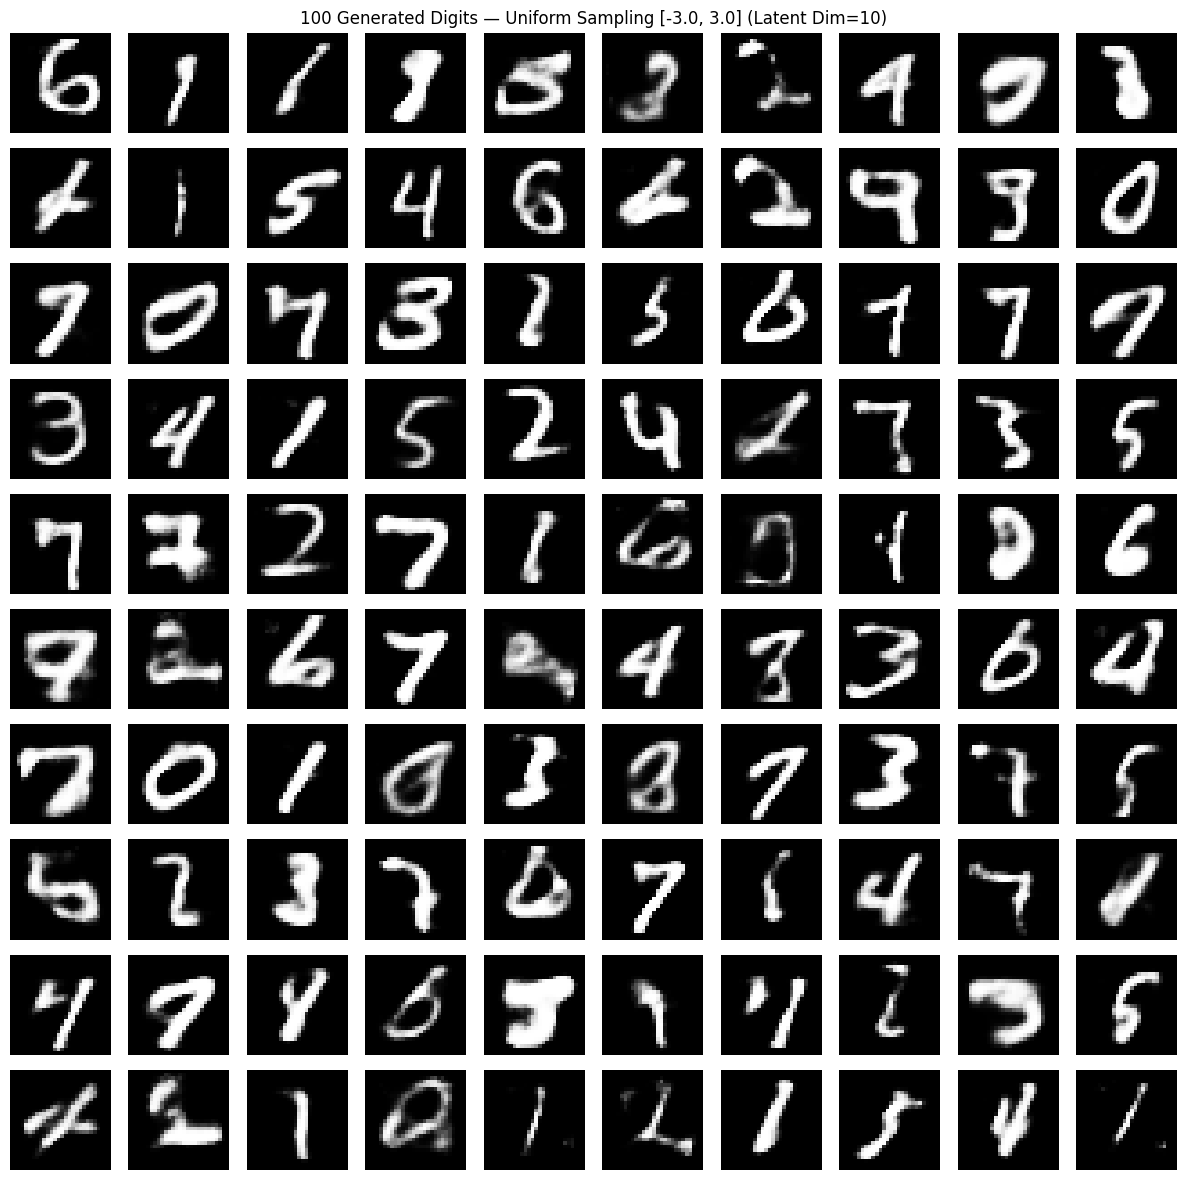

Saved uniform sampled generated digits for latent dim = 10


In [18]:
# now generating  uniform samples for 10D to show holes
# in 10D the holes are much more visible because the volume is enormous
generate_digits_uniform(vae_10d, latent_dim=10, n=100, low=-3.0, high=3.0)

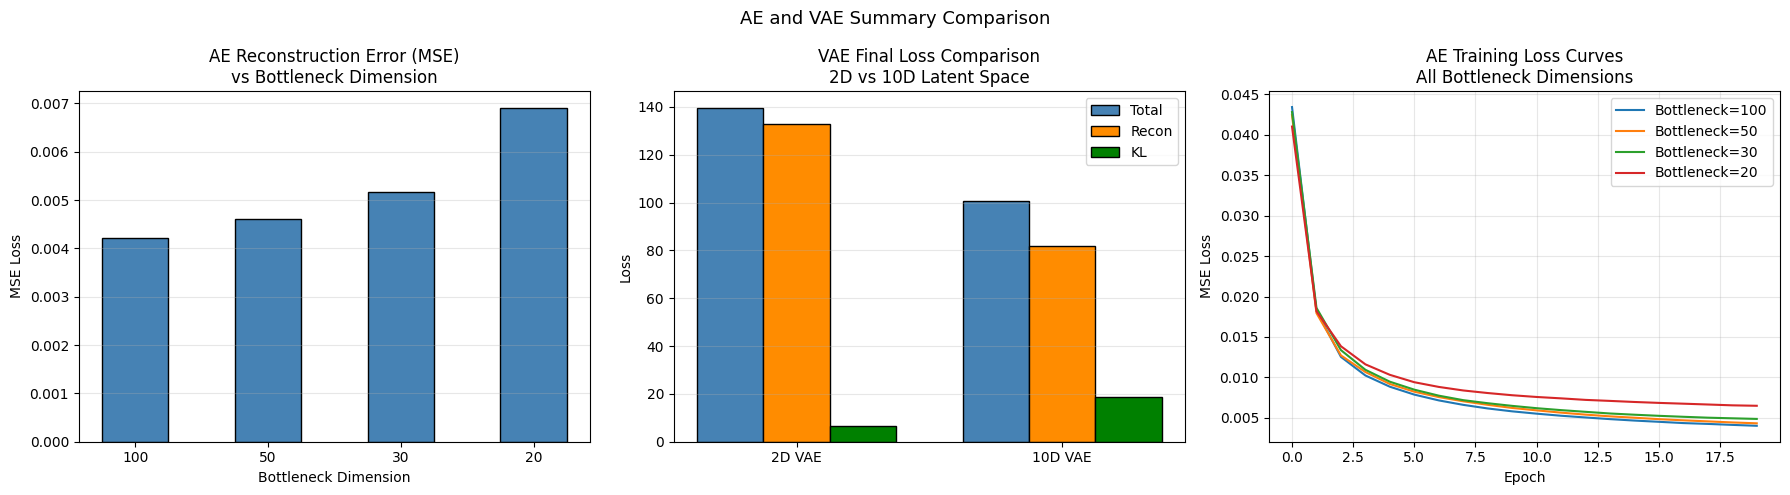

Saved final summary comparison plot


In [21]:
# comparison plot
# side by side comparison of AE reconstruction errors
# and VAE loss comparison between 2D and 10D

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AE and VAE Summary Comparison', fontsize=13)

# plot 1: AE reconstruction error vs bottleneck dim
dims   = list(ae_recon_errors.keys())
errors = list(ae_recon_errors.values())
axes[0].bar([str(d) for d in dims], errors, color='steelblue', edgecolor='black', width=0.5)
axes[0].set_title('AE Reconstruction Error (MSE)\nvs Bottleneck Dimension')
axes[0].set_xlabel('Bottleneck Dimension')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(axis='y', alpha=0.3)

# plot 2: VAE total loss comparison 2D vs 10D
vae_labels      = ['2D VAE', '10D VAE']
total_losses    = [history_2d['total'][-1], history_10d['total'][-1]]
recon_losses    = [history_2d['recon'][-1], history_10d['recon'][-1]]
kl_losses       = [history_2d['kl'][-1],    history_10d['kl'][-1]]

x     = np.arange(len(vae_labels))
width = 0.25

axes[1].bar(x - width, total_losses, width, label='Total',  color='steelblue',  edgecolor='black')
axes[1].bar(x,         recon_losses, width, label='Recon',  color='darkorange', edgecolor='black')
axes[1].bar(x + width, kl_losses,   width, label='KL',     color='green',      edgecolor='black')
axes[1].set_title('VAE Final Loss Comparison\n2D vs 10D Latent Space')
axes[1].set_xticks(x)
axes[1].set_xticklabels(vae_labels)
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# plot 3: AE loss curves for all bottleneck dims
for dim in bottleneck_dims:
    axes[2].plot(ae_losses[dim], label=f'Bottleneck={dim}')
axes[2].set_title('AE Training Loss Curves\nAll Bottleneck Dimensions')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved final summary comparison plot")

In [22]:
from PIL import Image, ImageDraw
import os

# combined AE reconstructions 2x2 grid
imgs = {
    100: Image.open('ae_reconstruction_dim_100.png'),
    50:  Image.open('ae_reconstruction_dim_50.png'),
    30:  Image.open('ae_reconstruction_dim_30.png'),
    20:  Image.open('ae_reconstruction_dim_20.png'),
}

target_w = 900
resized = {}
for dim, img in imgs.items():
    ratio = target_w / img.width
    resized[dim] = img.resize((target_w, int(img.height * ratio)), Image.LANCZOS)

cell_h = resized[100].height + 30
grid = Image.new('RGB', (target_w * 2 + 10, cell_h * 2 + 10), (255, 255, 255))
draw = ImageDraw.Draw(grid)
positions = [(0, 0, 100), (target_w + 10, 0, 50), (0, cell_h + 10, 30), (target_w + 10, cell_h + 10, 20)]
for x, y, dim in positions:
    grid.paste(resized[dim], (x, y + 28))
    draw.text((x + 5, y + 5), f'Bottleneck Dim = {dim}', fill=(0, 0, 0))
grid.save('ae_recon_combined.png', dpi=(150, 150))
print("Saved ae_recon_combined.png")

# helper to resize by height
def resize_h(img, h):
    return img.resize((int(img.width * h / img.height), h), Image.LANCZOS)

# combined standard normal sampling 2D and 10D side by side
sn2  = Image.open('vae_generated_standard_normal_dim_2.png')
sn10 = Image.open('vae_generated_standard_normal_dim_10.png')
sn2r  = resize_h(sn2,  500)
sn10r = resize_h(sn10, 500)
combined_sn = Image.new('RGB', (sn2r.width + sn10r.width + 10, 500), (255, 255, 255))
combined_sn.paste(sn2r,  (0, 0))
combined_sn.paste(sn10r, (sn2r.width + 10, 0))
combined_sn.save('vae_gen_normal_combined.png', dpi=(150, 150))
print("Saved vae_gen_normal_combined.png")

# combined uniform sampling 2D and 10D side by side
u2  = Image.open('vae_generated_uniform_dim_2.png')
u10 = Image.open('vae_generated_uniform_dim_10.png')
u2r  = resize_h(u2,  500)
u10r = resize_h(u10, 500)
combined_u = Image.new('RGB', (u2r.width + u10r.width + 10, 500), (255, 255, 255))
combined_u.paste(u2r,  (0, 0))
combined_u.paste(u10r, (u2r.width + 10, 0))
combined_u.save('vae_gen_uniform_combined.png', dpi=(150, 150))
print("Saved vae_gen_uniform_combined.png")

# combined latent space plot and VAE 2D loss curves side by side
ls  = Image.open('vae_latent_space_dim_2.png')
lc2 = Image.open('vae_loss_curves_dim_2.png')
ls_r  = resize_h(ls,  280)
lc2_r = resize_h(lc2, 280)
combined_ls = Image.new('RGB', (ls_r.width + lc2_r.width + 10, 280), (255, 255, 255))
combined_ls.paste(ls_r,  (0, 0))
combined_ls.paste(lc2_r, (ls_r.width + 10, 0))
combined_ls.save('vae_latent_and_loss.png', dpi=(150, 150))
print("Saved vae_latent_and_loss.png")



Saved ae_recon_combined.png
Saved vae_gen_normal_combined.png
Saved vae_gen_uniform_combined.png
Saved vae_latent_and_loss.png


In [23]:
ls10 = Image.open('vae_latent_space_tsne_dim_10.png')
ls2  = Image.open('vae_latent_space_dim_2.png')
ls2r  = resize_h(ls2,  400)
ls10r = resize_h(ls10, 400)
combined = Image.new('RGB', (ls2r.width + ls10r.width + 10, 400), (255,255,255))
combined.paste(ls2r, (0,0))
combined.paste(ls10r, (ls2r.width+10, 0))
combined.save('vae_latent_both.png', dpi=(150,150))

lc2  = Image.open('vae_loss_curves_dim_2.png')
lc10 = Image.open('vae_loss_curves_dim_10.png')
lc2r  = resize_h(lc2,  280)
lc10r = resize_h(lc10, 280)
combined_lc = Image.new('RGB', (lc2r.width + lc10r.width + 10, 280), (255,255,255))
combined_lc.paste(lc2r, (0,0))
combined_lc.paste(lc10r, (lc2r.width+10, 0))
combined_lc.save('vae_loss_both.png', dpi=(150,150))
print("Done — vae_latent_both.png and vae_loss_both.png saved")

Done — vae_latent_both.png and vae_loss_both.png saved
